<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/06_Transformer/Korean_Transformer_Chatbot_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Korean Transformer Chatbot — Final Draft

한국어 대화 데이터셋을 이용해 **Transformer Encoder–Decoder 기반 챗봇**을 학습하고 테스트하는 실험용 노트북입니다.

### 실험 흐름
1. 데이터셋 다운로드 및 확인
2. 텍스트 정제 및 Train/Validation 분리
3. Vocabulary / Tokenization
4. Transformer Seq2Seq 모델 구성
5. 학습 및 Validation
6. Best checkpoint 저장 및 로드
7. 테스트 문장에 대한 응답 생성
8. **최종 결과 + Hyperparameters + Training Parameters 출력**


## 1. Imports

In [1]:
import os
import re
import random
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


## 2. Reproducibility & Device

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cuda


## 3. Hyperparameters

In [3]:
N_LAYERS = 1
D_MODEL = 368
N_HEADS = 8
D_FF = 1024
DROPOUT = 0.2

WARMUP_STEPS = 1000
BATCH_SIZE = 64
EPOCHS = 10
MAX_LEN = 40

print("Model Hyperparameters")
print(f"n_layers: {N_LAYERS}")
print(f"d_model: {D_MODEL}")
print(f"n_heads: {N_HEADS}")
print(f"d_ff: {D_FF}")
print(f"dropout: {DROPOUT}")

print("\nTraining Parameters")
print(f"Warmup Steps: {WARMUP_STEPS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print("Optimizer: Adam")
print("Adam β1=0.9, β2=0.98, ε=1e-9")


Model Hyperparameters
n_layers: 1
d_model: 368
n_heads: 8
d_ff: 1024
dropout: 0.2

Training Parameters
Warmup Steps: 1000
Batch Size: 64
Epochs: 10
Optimizer: Adam
Adam β1=0.9, β2=0.98, ε=1e-9


## 4. Special Tokens

In [4]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

PAD_IDX = 0
UNK_IDX = 1
SOS_IDX = 2
EOS_IDX = 3


## 5. Download & Load Chatbot Dataset

In [5]:
DATA_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
DATA_PATH = "ChatbotData.csv"

if not os.path.exists(DATA_PATH):
    import urllib.request
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 6. Text Cleaning

In [6]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"[^가-힣a-zA-Z0-9\s.,!?~]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ChatbotData.csv uses Q/A columns.
question_col = "Q"
answer_col = "A"

df[question_col] = df[question_col].apply(clean_text)
df[answer_col] = df[answer_col].apply(clean_text)

df = df[(df[question_col] != "") & (df[answer_col] != "")].reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
display(df.head())


Cleaned dataset shape: (11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 7. Train / Validation Split

In [7]:
indices = np.arange(len(df))
np.random.shuffle(indices)

split_idx = int(len(indices) * 0.9)

train_df = df.iloc[indices[:split_idx]].reset_index(drop=True)
valid_df = df.iloc[indices[split_idx:]].reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(valid_df))


Train: 10640
Validation: 1183


## 8. Tokenization & Vocabulary

In [8]:
def tokenize(text):
    return text.split()

counter = {}

for text in pd.concat([train_df[question_col], train_df[answer_col]]):
    for token in tokenize(text):
        counter[token] = counter.get(token, 0) + 1

itos = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN] + sorted(counter.keys())
stoi = {token: idx for idx, token in enumerate(itos)}

VOCAB_SIZE = len(itos)

print("Vocabulary size:", VOCAB_SIZE)

def encode(text):
    tokens = tokenize(text)
    ids = [SOS_IDX]
    ids += [stoi.get(token, UNK_IDX) for token in tokens]
    ids += [EOS_IDX]
    return ids[:MAX_LEN]


Vocabulary size: 20424


## 9. Dataset & Collate

In [9]:
class ChatbotDataset(Dataset):
    def __init__(self, dataframe):
        self.questions = dataframe[question_col].tolist()
        self.answers = dataframe[answer_col].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        return encode(self.questions[idx]), encode(self.answers[idx])


def pad_sequence_list(sequences, pad_value=PAD_IDX):
    max_len = max(len(seq) for seq in sequences)
    result = []
    for seq in sequences:
        result.append(seq + [pad_value] * (max_len - len(seq)))
    return torch.tensor(result, dtype=torch.long)


def collate_fn(batch):
    src, tgt = zip(*batch)
    src = pad_sequence_list(src)
    tgt = pad_sequence_list(tgt)
    return src, tgt


train_dataset = ChatbotDataset(train_df)
valid_dataset = ChatbotDataset(valid_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))


Train batches: 167
Validation batches: 19


## 10. Positional Encoding

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


## 11. Transformer Seq2Seq Model

In [11]:
class TransformerChatbot(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=D_MODEL,
        nhead=N_HEADS,
        num_layers=N_LAYERS,
        dim_feedforward=D_FF,
        dropout=DROPOUT
    ):
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_IDX
        )

        self.positional_encoding = PositionalEncoding(
            d_model,
            max_len=MAX_LEN
        )

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(
        self,
        src,
        tgt,
        src_key_padding_mask=None,
        tgt_key_padding_mask=None,
        tgt_mask=None
    ):
        src_emb = self.embedding(src) * math.sqrt(self.d_model)
        tgt_emb = self.embedding(tgt) * math.sqrt(self.d_model)

        src_emb = self.positional_encoding(src_emb)
        tgt_emb = self.positional_encoding(tgt_emb)

        output = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )

        return self.fc_out(output)


model = TransformerChatbot(VOCAB_SIZE).to(device)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))


TransformerChatbot(
  (embedding): Embedding(20424, 368, padding_idx=0)
  (positional_encoding): PositionalEncoding()
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=368, out_features=368, bias=True)
          )
          (linear1): Linear(in_features=368, out_features=1024, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=1024, out_features=368, bias=True)
          (norm1): LayerNorm((368,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((368,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.2, inplace=False)
          (dropout2): Dropout(p=0.2, inplace=False)
        )
      )
      (norm): LayerNorm((368,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDecoder(
      (layers): 

## 12. Causal Mask

In [12]:
def generate_square_subsequent_mask(size, device):
    return torch.triu(
        torch.ones(size, size, device=device, dtype=torch.bool),
        diagonal=1
    )


## 13. Optimizer & Noam Learning Rate

In [13]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

def noam_rate(step, d_model=D_MODEL, warmup_steps=WARMUP_STEPS):
    step = max(step, 1)
    return d_model ** (-0.5) * min(
        step ** (-0.5),
        step * warmup_steps ** (-1.5)
    )


## 14. Loss Function

In [14]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


## 15. Training / Validation

In [15]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0.0

    for src, tgt in loader:
        src = src.to(device)
        tgt = tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        tgt_mask = generate_square_subsequent_mask(
            tgt_input.size(1),
            device
        )

        src_padding_mask = src.eq(PAD_IDX)
        tgt_padding_mask = tgt_input.eq(PAD_IDX)

        with torch.set_grad_enabled(train):
            logits = model(
                src,
                tgt_input,
                src_key_padding_mask=src_padding_mask,
                tgt_key_padding_mask=tgt_padding_mask,
                tgt_mask=tgt_mask
            )

            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                tgt_output.reshape(-1)
            )

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


## 16. Train the Model

In [16]:
train_losses = []
valid_losses = []
learning_rates = []

best_valid_loss = float("inf")
global_step = 0

for epoch in range(1, EPOCHS + 1):

    model.train()

    total_train_loss = 0.0

    for src, tgt in train_loader:
        src = src.to(device)
        tgt = tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        tgt_mask = generate_square_subsequent_mask(
            tgt_input.size(1),
            device
        )

        src_padding_mask = src.eq(PAD_IDX)
        tgt_padding_mask = tgt_input.eq(PAD_IDX)

        logits = model(
            src,
            tgt_input,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            tgt_mask=tgt_mask
        )

        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            tgt_output.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        global_step += 1
        lr = noam_rate(global_step)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        optimizer.step()

        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)

    valid_loss = run_epoch(valid_loader, train=False)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    learning_rates.append(optimizer.param_groups[0]["lr"])

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "korean_chatbot_transformer.pt")

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | "
        f"LR: {learning_rates[-1]:.6f}"
    )


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 01/10 | Train Loss: 7.9466 | Valid Loss: 7.0978 | LR: 0.000275
Epoch 02/10 | Train Loss: 6.4878 | Valid Loss: 6.6538 | LR: 0.000551
Epoch 03/10 | Train Loss: 5.7490 | Valid Loss: 6.2943 | LR: 0.000826
Epoch 04/10 | Train Loss: 4.8803 | Valid Loss: 5.9394 | LR: 0.001101
Epoch 05/10 | Train Loss: 4.1408 | Valid Loss: 5.8494 | LR: 0.001376
Epoch 06/10 | Train Loss: 3.6344 | Valid Loss: 5.8807 | LR: 0.001647
Epoch 07/10 | Train Loss: 3.3314 | Valid Loss: 6.0066 | LR: 0.001525
Epoch 08/10 | Train Loss: 3.0134 | Valid Loss: 6.0160 | LR: 0.001426
Epoch 09/10 | Train Loss: 2.6818 | Valid Loss: 6.0902 | LR: 0.001345
Epoch 10/10 | Train Loss: 2.4137 | Valid Loss: 5.9893 | LR: 0.001276


## 17. Loss Curve

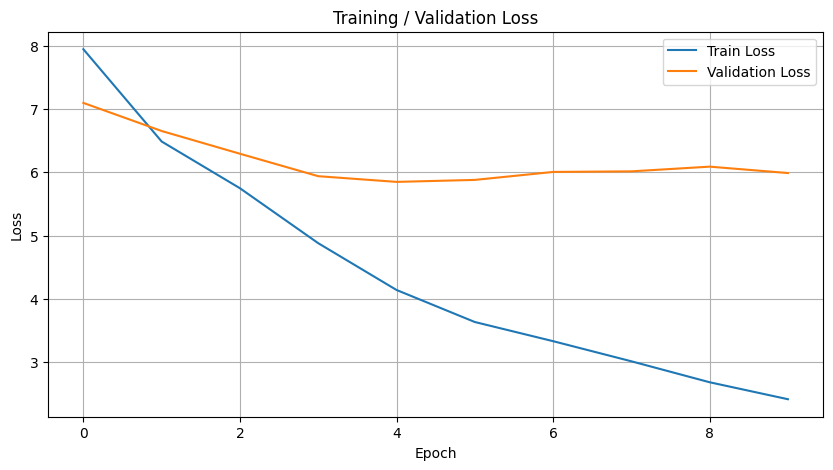

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


## 18. Load Best Model

In [18]:
model.load_state_dict(
    torch.load(
        "korean_chatbot_transformer.pt",
        map_location=device
    )
)

model.eval()

print("Best model loaded.")
print("Best validation loss:", best_valid_loss)


Best model loaded.
Best validation loss: 5.849430510872288


## 19. Greedy Response Generation

In [19]:
@torch.no_grad()
def generate_response(sentence, max_len=MAX_LEN):
    model.eval()

    src = torch.tensor(
        [encode(sentence)],
        dtype=torch.long,
        device=device
    )

    src_padding_mask = src.eq(PAD_IDX)

    generated = [SOS_IDX]

    for _ in range(max_len - 1):

        tgt = torch.tensor(
            [generated],
            dtype=torch.long,
            device=device
        )

        tgt_mask = generate_square_subsequent_mask(
            tgt.size(1),
            device
        )

        tgt_padding_mask = tgt.eq(PAD_IDX)

        output = model(
            src,
            tgt,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            tgt_mask=tgt_mask
        )

        next_token = output[:, -1, :].argmax(dim=-1).item()

        generated.append(next_token)

        if next_token == EOS_IDX:
            break

    tokens = [
        itos[idx]
        for idx in generated
        if idx not in (SOS_IDX, EOS_IDX, PAD_IDX)
    ]

    return " ".join(tokens)


## 20. Test Sentences

In [20]:
test_sentences = [
    "안녕하세요.",
    "오늘 기분이 좋아.",
    "요즘 너무 힘들어.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

for sentence in test_sentences:
    response = generate_response(sentence)
    print(f"입력 : {sentence}")
    print(f"응답 : {response}")
    print()


입력 : 안녕하세요.
응답 : 이제 좀 더 버텨보세요.

입력 : 오늘 기분이 좋아.
응답 : 저도 사는데요.

입력 : 요즘 너무 힘들어.
응답 : 좋은 곳으로 데려다 줄 거예요.

입력 : 간만에 여자친구랑 데이트 하기로 했어.
응답 : 저도 사는데요.

입력 : 집에 있는다는 소리야.
응답 : 좋은 사람 만날 수 있을 거예요.



## 21. BLEU Evaluation

생성된 챗봇 응답과 정답 응답(`A`)을 비교하여 **BLEU score**를 계산합니다.

- BLEU는 생성 문장과 reference 문장의 n-gram overlap을 측정하는 정량 평가 지표입니다.
- 여기서는 한국어 공백 토큰 기준으로 평가합니다.
- 최종 평가는 **Validation Loss + BLEU + 실제 생성 응답**을 함께 확인합니다.


In [21]:
# BLEU evaluation
!pip -q install nltk

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

references = []
hypotheses = []

# Validation set을 정량 평가에 사용
for _, row in valid_df.iterrows():
    source = row[question_col]
    reference = row[answer_col]

    prediction = generate_response(source)

    references.append([tokenize(reference)])
    hypotheses.append(tokenize(prediction))

smooth = SmoothingFunction().method1

bleu_score = corpus_bleu(
    references,
    hypotheses,
    smoothing_function=smooth
)

print("=" * 70)
print("BLEU Evaluation")
print("=" * 70)
print(f"BLEU Score: {bleu_score:.4f}")
print(f"Evaluated samples: {len(hypotheses)}")


BLEU Evaluation
BLEU Score: 0.0038
Evaluated samples: 1183


## 22. Final Output

최종 제출/실험 결과를 한 번에 확인합니다.

- BLEU Score
- 테스트 문장별 Chatbot Responses
- Model Hyperparameters
- Training Parameters


In [23]:
print("\n" + "=" * 70)
print("Final Evaluation")
print("=" * 70)
print(f"BLEU Score: {bleu_score:.4f}")

print("\n" + "=" * 70)
print("Chatbot Responses")
print("=" * 70)

for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence)
    print(f"{i}. 입력 : {sentence}")
    print(f"   응답 : {response}")

print("\n" + "=" * 70)
print("Model Hyperparameters")
print("=" * 70)
print(f"n_layers: {N_LAYERS}")
print(f"d_model: {D_MODEL}")
print(f"n_heads: {N_HEADS}")
print(f"d_ff: {D_FF}")
print(f"dropout: {DROPOUT}")

print("\n" + "=" * 70)
print("Training Parameters")
print("=" * 70)
print(f"Warmup Steps: {WARMUP_STEPS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print("Optimizer: Adam")
print("Adam β1=0.9, β2=0.98, ε=1e-9")


Final Evaluation
BLEU Score: 0.0038

Chatbot Responses
1. 입력 : 안녕하세요.
   응답 : 이제 좀 더 버텨보세요.
2. 입력 : 오늘 기분이 좋아.
   응답 : 저도 사는데요.
3. 입력 : 요즘 너무 힘들어.
   응답 : 좋은 곳으로 데려다 줄 거예요.
4. 입력 : 간만에 여자친구랑 데이트 하기로 했어.
   응답 : 저도 사는데요.
5. 입력 : 집에 있는다는 소리야.
   응답 : 좋은 사람 만날 수 있을 거예요.

Model Hyperparameters
n_layers: 1
d_model: 368
n_heads: 8
d_ff: 1024
dropout: 0.2

Training Parameters
Warmup Steps: 1000
Batch Size: 64
Epochs: 10
Optimizer: Adam
Adam β1=0.9, β2=0.98, ε=1e-9


## 23. Experiment Guide

### Baseline
```text
N_LAYERS = 1
D_MODEL = 368
N_HEADS = 8
D_FF = 1024
DROPOUT = 0.2
```

### Experiment A — Deeper
```text
N_LAYERS = 2
D_MODEL = 256
N_HEADS = 8
D_FF = 1024
```

### Experiment B — Larger Model
```text
N_LAYERS = 2
D_MODEL = 512
N_HEADS = 8
D_FF = 2048
```

실험할 때는 **한 번에 하나의 주요 하이퍼파라미터만 변경**하고 Loss와 최종 응답 품질을 비교하는 것이 좋습니다.
